## DATA PROCESSING

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import joblib


In [2]:
df = pd.read_csv(r"C:\Users\fadhl\OneDrive\Desktop\linear_regression_model\summative\student-mat.csv", sep=";")




In [3]:
# Check for null/missing values
df.isnull().sum().sort_values(ascending=False)


school        0
paid          0
G2            0
G1            0
absences      0
health        0
Walc          0
Dalc          0
goout         0
freetime      0
famrel        0
romantic      0
internet      0
higher        0
nursery       0
activities    0
famsup        0
sex           0
schoolsup     0
failures      0
studytime     0
traveltime    0
guardian      0
reason        0
Fjob          0
Mjob          0
Fedu          0
Medu          0
Pstatus       0
famsize       0
address       0
age           0
G3            0
dtype: int64

In [4]:
# Overview of data types and non-null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
# Descriptive statistics for numeric features
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [6]:
# Count duplicate rows
df.duplicated().sum()

# View duplicate rows 
df[df.duplicated()]


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3


In [7]:
# Check unique values in object (categorical) columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")


school: ['GP' 'MS']
sex: ['F' 'M']
address: ['U' 'R']
famsize: ['GT3' 'LE3']
Pstatus: ['A' 'T']
Mjob: ['at_home' 'health' 'other' 'services' 'teacher']
Fjob: ['teacher' 'other' 'services' 'health' 'at_home']
reason: ['course' 'other' 'home' 'reputation']
guardian: ['mother' 'father' 'other']
schoolsup: ['yes' 'no']
famsup: ['no' 'yes']
paid: ['no' 'yes']
activities: ['no' 'yes']
nursery: ['yes' 'no']
higher: ['yes' 'no']
internet: ['no' 'yes']
romantic: ['no' 'yes']


In [8]:
df_cleaned = df.copy()

# One-hot encode multi-class categorical columns
onehot_cols = ['school', 'Mjob', 'Fjob', 'reason', 'guardian']
df_cleaned = pd.get_dummies(df_cleaned, columns=onehot_cols, drop_first=True)

In [9]:
#  Label encode binary categorical columns
binary_cols = [
    'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid',
    'activities', 'nursery', 'higher', 'internet', 'romantic'
]

le = LabelEncoder()
for col in binary_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col])

In [10]:
#  Define features and target
X = df_cleaned.drop(columns=['G3'])
y = df_cleaned['G3']

In [11]:
# Standardize numeric features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,-0.948176,1.023046,0.535392,-0.636941,-2.938392,1.143856,1.360371,0.792251,-0.042286,-0.449944,...,-0.414858,-0.218507,-1.104129,-0.625176,3.552561,-0.617348,-0.316668,-0.601722,0.668496,-0.296908
1,-0.948176,0.238380,0.535392,-0.636941,0.340322,-1.600009,-1.399970,-0.643249,-0.042286,-0.449944,...,-0.414858,-0.218507,0.905691,-0.625176,-0.281487,-0.617348,-0.316668,-0.601722,-1.495896,-0.296908
2,-0.948176,-1.330954,0.535392,1.570004,0.340322,-1.600009,-1.399970,-0.643249,-0.042286,3.589323,...,-0.414858,-0.218507,0.905691,-0.625176,-0.281487,-0.617348,3.157883,-0.601722,0.668496,-0.296908
3,-0.948176,-1.330954,0.535392,-0.636941,0.340322,1.143856,-0.479857,-0.643249,1.150779,-0.449944,...,-0.414858,-0.218507,-1.104129,1.599549,-0.281487,1.619831,-0.316668,-0.601722,0.668496,-0.296908
4,-0.948176,-0.546287,0.535392,-0.636941,0.340322,0.229234,0.440257,-0.643249,-0.042286,-0.449944,...,-0.414858,-0.218507,0.905691,-0.625176,-0.281487,1.619831,-0.316668,-0.601722,-1.495896,-0.296908


In [12]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Training set: (316, 41) (316,)
Test set: (79, 41) (79,)


## LINEAR REGRESSION

In [13]:
# Initialize and fit the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

In [15]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

In [16]:
print(f"Train MSE: {train_mse:.2f}, RMSE: {train_rmse:.2f}")
print(f"Test MSE: {test_mse:.2f}, RMSE: {test_rmse:.2f}")

Train MSE: 2.82, RMSE: 1.68
Test MSE: 5.66, RMSE: 2.38


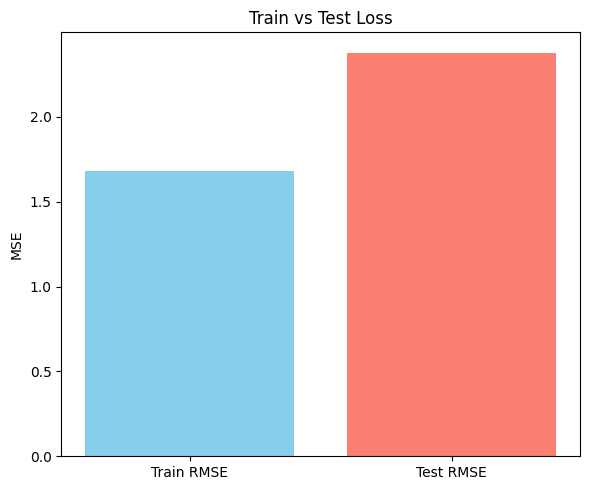

In [17]:
import matplotlib.pyplot as plt
loss_values = [train_rmse, test_rmse]
labels = ['Train RMSE', 'Test RMSE']

# Plot
plt.figure(figsize=(6, 5))
plt.bar(labels, loss_values, color=['skyblue', 'salmon'])
plt.title('Train vs Test Loss')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()


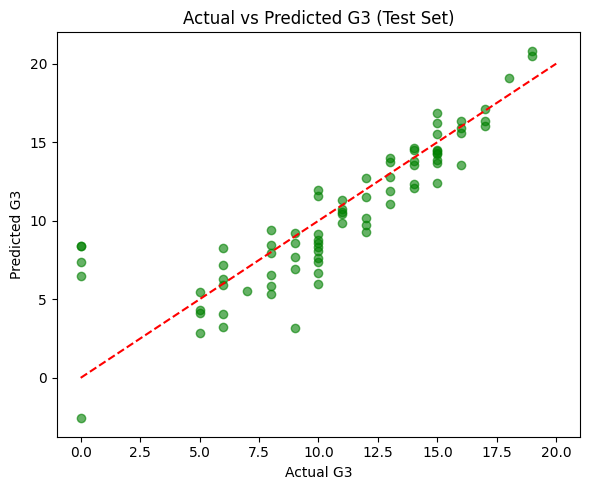

In [18]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_test_pred, color='green', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # identity line
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Actual vs Predicted G3 (Test Set)')
plt.tight_layout()
plt.show()


## DECISION TREE

In [19]:
# Initialize and train the model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [20]:
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

In [21]:
# Evaluate
train_mse_dt = mean_squared_error(y_train, y_train_pred_dt)
test_mse_dt = mean_squared_error(y_test, y_test_pred_dt)
train_rmse_dt = np.sqrt(train_mse_dt)
test_rmse_dt = np.sqrt(test_mse_dt)

In [22]:
print(f"Train MSE: {train_mse_dt:.2f}, RMSE: {train_rmse_dt:.2f}")
print(f"Test MSE: {test_mse_dt:.2f}, RMSE: {test_rmse_dt:.2f}")

Train MSE: 0.00, RMSE: 0.00
Test MSE: 6.89, RMSE: 2.62


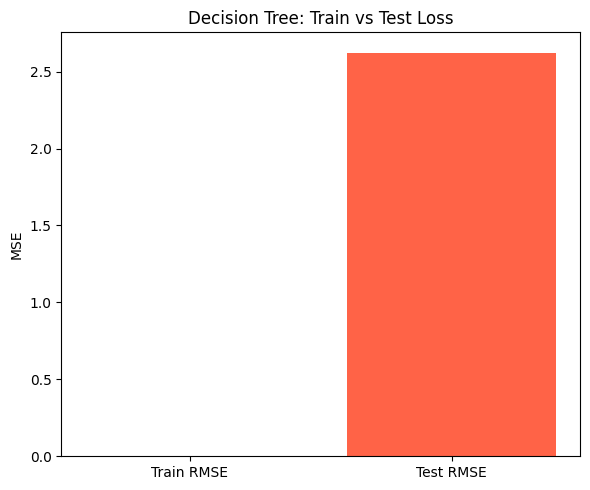

In [23]:
plt.figure(figsize=(6, 5))
plt.bar(['Train RMSE', 'Test RMSE'], [train_rmse_dt, test_rmse_dt], color=['mediumseagreen', 'tomato'])
plt.title('Decision Tree: Train vs Test Loss')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()

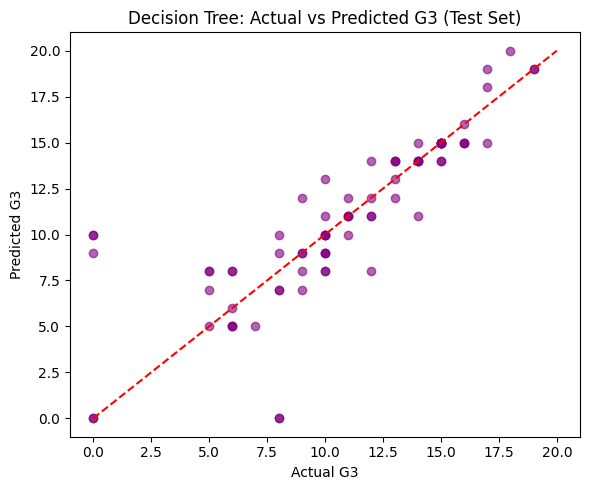

In [24]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_test_pred_dt, color='purple', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # perfect line
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Decision Tree: Actual vs Predicted G3 (Test Set)')
plt.tight_layout()
plt.show()


## RANDOM FOREST

In [25]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [26]:
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

In [27]:
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)
train_rmse_rf = np.sqrt(train_mse_rf)
test_rmse_rf = np.sqrt(test_mse_rf)




In [28]:
# Print results
print(f"Random Forest - Train MSE: {train_mse_rf:.2f}, RMSE: {train_rmse_rf:.2f}")
print(f"Random Forest - Test MSE: {test_mse_rf:.2f}, RMSE: {test_rmse_rf:.2f}")

Random Forest - Train MSE: 0.33, RMSE: 0.57
Random Forest - Test MSE: 3.94, RMSE: 1.99


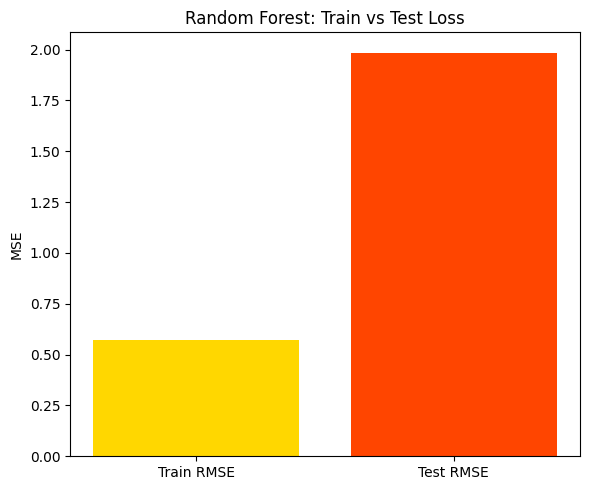

In [29]:
# Bar plot of train vs test MSE for Random Forest
plt.figure(figsize=(6, 5))
plt.bar(['Train RMSE', 'Test RMSE'], [train_rmse_rf, test_rmse_rf], color=['gold', 'orangered'])
plt.title('Random Forest: Train vs Test Loss')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()


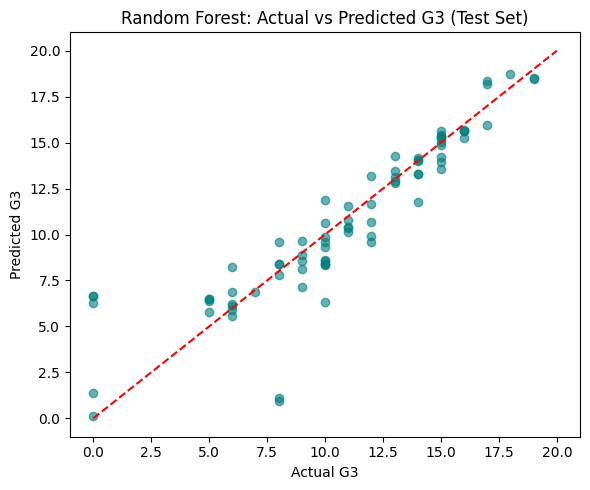

In [30]:
# Scatter plot of actual vs predicted G3 (Random Forest)
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_test_pred_rf, color='teal', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # ideal line
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Random Forest: Actual vs Predicted G3 (Test Set)')
plt.tight_layout()
plt.show()


In [31]:
# Compare models based on test RMSE score
model_scores = {
    'Linear Regression': test_rmse,
    'Decision Tree': test_rmse_dt,
    'Random Forest': test_rmse_rf
}

for name, rmse in model_scores.items():
    print(f"{name} Test RMSE: {rmse:.3f}")


Linear Regression Test RMSE: 2.378
Decision Tree Test RMSE: 2.624
Random Forest Test RMSE: 1.986


In [32]:
# Find best model
best_model_name = min(model_scores, key=model_scores.get)
print(f"\n✅ Best model: {best_model_name}")



✅ Best model: Random Forest


In [33]:
# Save the best model and the scaler
if best_model_name == 'Linear Regression':
    best_model = lr_model
elif best_model_name == 'Decision Tree':
    best_model = dt_model
else:
    best_model = rf_model

# Save model and scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Best model and scaler saved as 'best_model.pkl' and 'scaler.pkl'")


✅ Best model and scaler saved as 'best_model.pkl' and 'scaler.pkl'


In [34]:
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')

['feature_columns.pkl']